Name :- Abhijeet Dinakar Pathade

Roll_No. :- 16

Division :- A

#  KNN Classification on the Pima Indians Diabetes Dataset

This notebook builds a **K-Nearest Neighbors (KNN)** classifier that predicts whether a patient has diabetes based on diagnostic measurements.

**Workflow**
1. Load and inspect the data
2. Clean invalid (zero-coded) medical readings
3. Explore the data visually
4. Split and scale the features
5. Tune the hyperparameter **K** using cross-validation
6. Train the final model and evaluate it (accuracy, confusion matrix, ROC-AUC)
7. Summarize findings

**Dataset:** Pima Indians Diabetes Database — 768 female patients, 8 medical predictor variables, and a binary target `Outcome` (1 = diabetic, 0 = not diabetic).


## 1. Setup & Imports

In [ ]:
# Core libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

# Modeling
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay, roc_curve, roc_auc_score
)

RANDOM_STATE = 42
print("Libraries loaded.")

Libraries loaded.


## 2. Load the Dataset

The dataset is fetched directly from a public GitHub mirror of the Pima Indians Diabetes Database, so this cell will work as-is in Google Colab (internet access required).

If the URL ever becomes unavailable, you can instead:
- Download `diabetes.csv` from [Kaggle: uciml/pima-indians-diabetes-database](https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database), then
- Upload it in Colab with the file-upload cell provided (commented out below).

In [ ]:
url = "/content/drive/MyDrive/diabetes_dataset.csv"
df = pd.read_csv(url)

# --- Alternative: upload the CSV manually in Colab ---
# from google.colab import files
# uploaded = files.upload()
# df = pd.read_csv(list(uploaded.keys())[0])

print("Shape:", df.shape)
df.head()

Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 3. Exploratory Data Analysis

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


### Class balance

Diabetes datasets are commonly imbalanced. Let's check how many patients are diabetic (`Outcome = 1`) vs not (`Outcome = 0`).

Outcome
0    500
1    268
Name: count, dtype: int64
Outcome
0    65.1
1    34.9
Name: proportion, dtype: float64 %


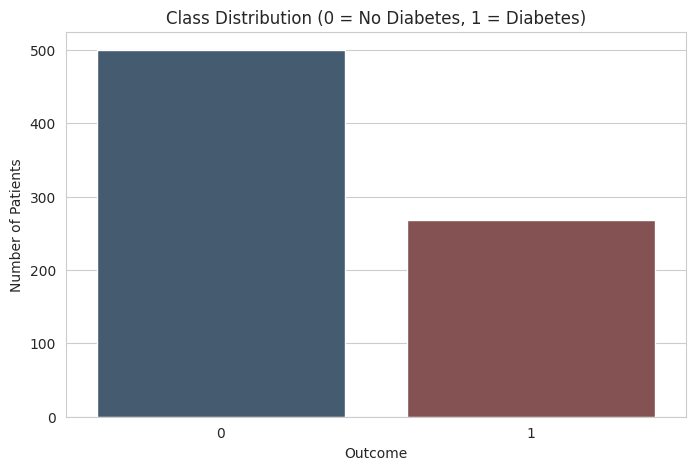

In [ ]:
print(df["Outcome"].value_counts())
print(df["Outcome"].value_counts(normalize=True).round(3) * 100, "%")

sns.countplot(x="Outcome", hue="Outcome", data=df, palette=["#3E5C76", "#8C4A4A"], legend=False)
plt.title("Class Distribution (0 = No Diabetes, 1 = Diabetes)")
plt.xlabel("Outcome")
plt.ylabel("Number of Patients")
plt.show()

### Hidden missing values

Several columns cannot biologically be `0` (e.g. `Glucose`, `BloodPressure`, `BMI`). In this dataset those missing readings were encoded as `0`. Let's find them before cleaning.

In [ ]:
zero_invalid_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

zero_counts = (df[zero_invalid_cols] == 0).sum()
print("Number of zero (likely missing) values per column:")
print(zero_counts)

Number of zero (likely missing) values per column:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


## 4. Data Cleaning

We replace the biologically-impossible zeros with `NaN`, then impute them using the **median of each column, computed separately per class** (`Outcome`). This keeps the imputed values consistent with whether the patient is diabetic or not, which is more informative than a single global median.

In [ ]:
df_clean = df.copy()
df_clean[zero_invalid_cols] = df_clean[zero_invalid_cols].replace(0, np.nan)

# Impute with the median of each column, computed per Outcome class
for col in zero_invalid_cols:
    df_clean[col] = df_clean.groupby("Outcome")[col].transform(lambda s: s.fillna(s.median()))

print("Remaining missing values:\n", df_clean.isna().sum().sum())
df_clean.describe().T

Remaining missing values:
 0


,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,121.677083,30.464161,44.000,99.75000,117.0000,140.25000,199.00
BloodPressure,768.0,72.389323,12.106039,24.000,64.00000,72.0000,80.00000,122.00
SkinThickness,768.0,29.089844,8.890820,7.000,25.00000,28.0000,32.00000,99.00
Insulin,768.0,141.753906,89.100847,14.000,102.50000,102.5000,169.50000,846.00
BMI,768.0,32.434635,6.880498,18.200,27.50000,32.0500,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


## 5. Visualizing the Data

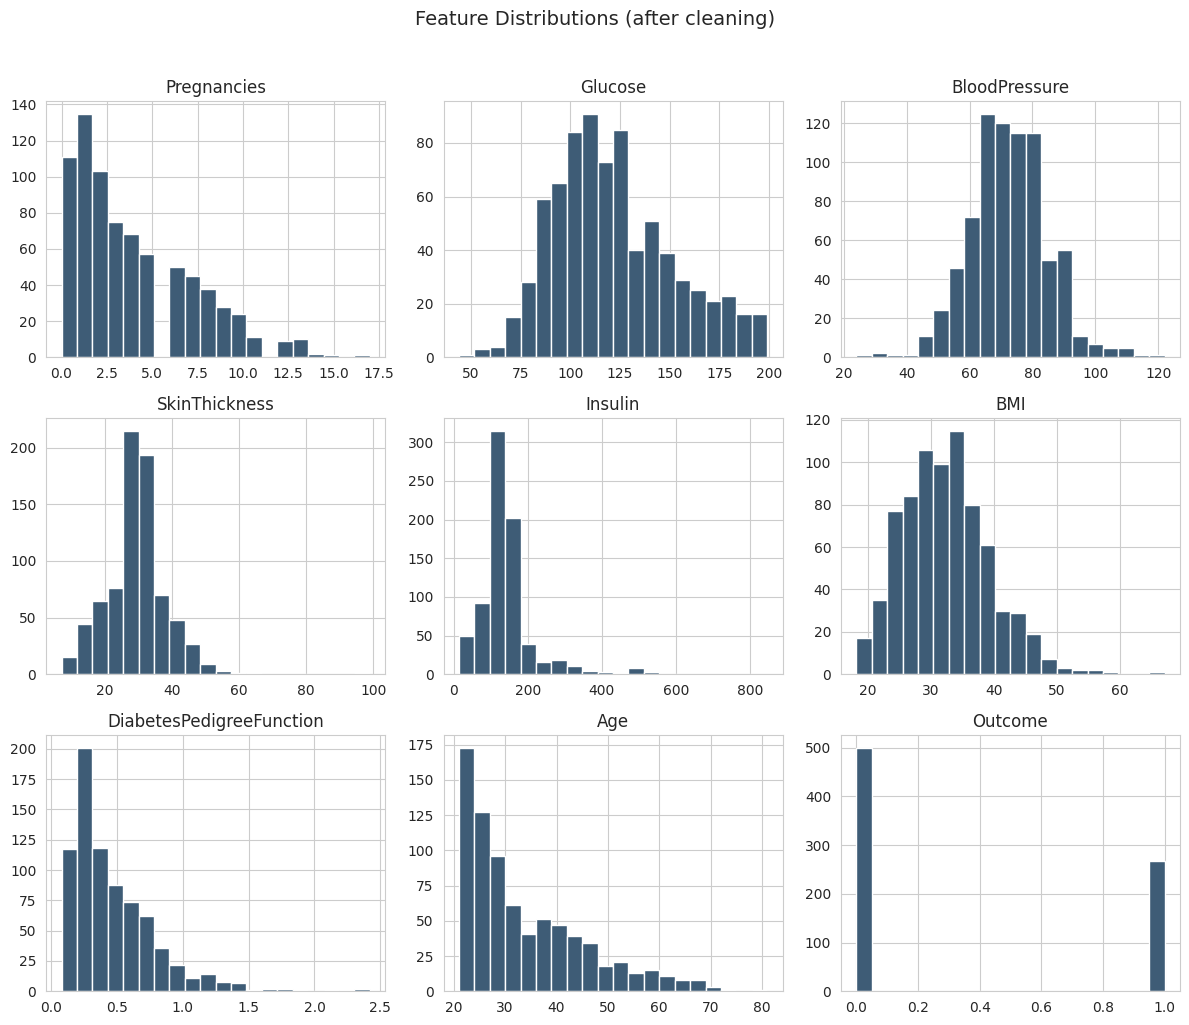

In [ ]:
df_clean.hist(figsize=(12, 10), bins=20, color="#3E5C76", edgecolor="white")
plt.suptitle("Feature Distributions (after cleaning)", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

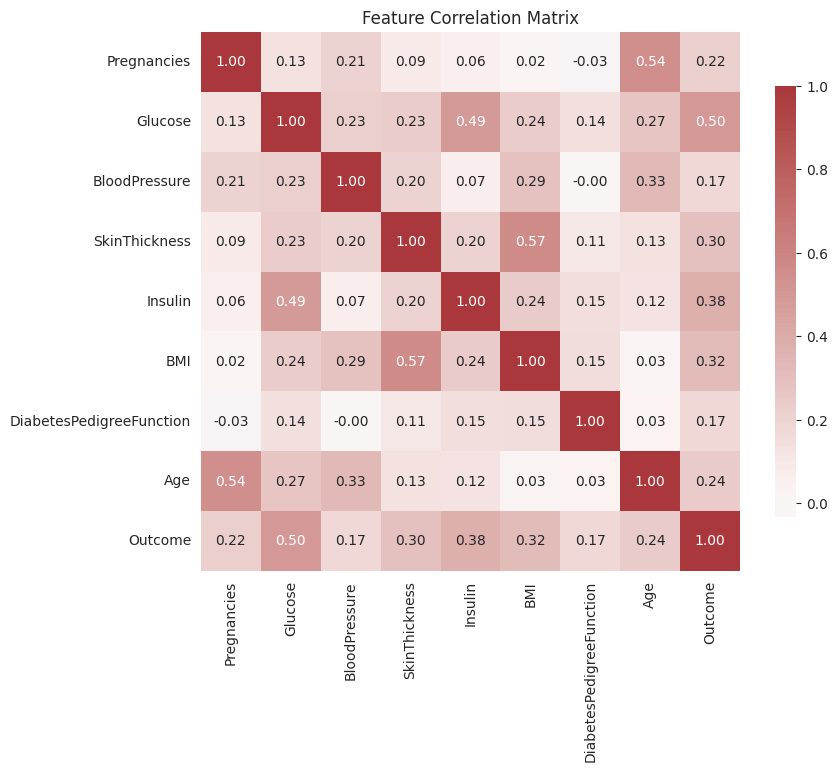

In [ ]:
plt.figure(figsize=(9, 7))
corr = df_clean.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0, square=True, cbar_kws={"shrink": 0.8})
plt.title("Feature Correlation Matrix")
plt.show()

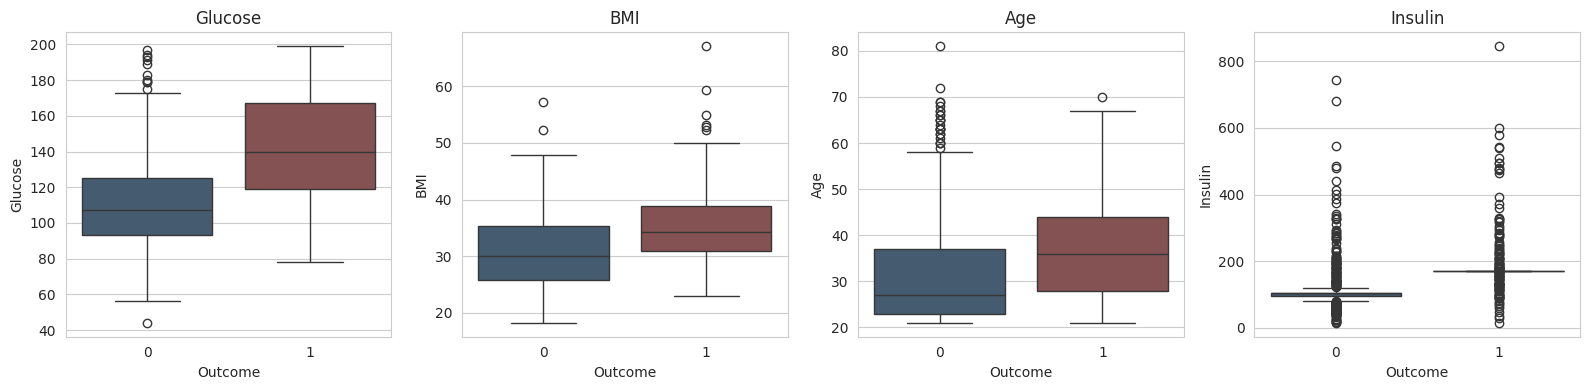

In [ ]:
features_to_plot = ["Glucose", "BMI", "Age", "Insulin"]

fig, axes = plt.subplots(1, len(features_to_plot), figsize=(16, 4))
for ax, feat in zip(axes, features_to_plot):
    sns.boxplot(x="Outcome", y=feat, hue="Outcome", data=df_clean, ax=ax, palette=["#3E5C76", "#8C4A4A"], legend=False)
    ax.set_title(feat)
plt.tight_layout()
plt.show()

## 6. Train/Test Split & Feature Scaling

KNN is a **distance-based** algorithm, so features must be on comparable scales — otherwise a large-range feature like `Insulin` would dominate the distance calculation over a small-range feature like `DiabetesPedigreeFunction`. We standardize all features to zero mean and unit variance using `StandardScaler`, fit **only on the training set** to avoid data leakage.

In [ ]:
X = df_clean.drop(columns=["Outcome"])
y = df_clean["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train_scaled.shape)
print("Test shape :", X_test_scaled.shape)

Train shape: (614, 8)
Test shape : (154, 8)


## 7. Choosing the Best K

We evaluate odd values of K from 1 to 30 using 10-fold cross-validation on the training set, then plot mean accuracy vs. K to pick the value that generalizes best (avoiding both overfitting at low K and underfitting at high K).

Best K found: 17 (CV accuracy = 0.8242)


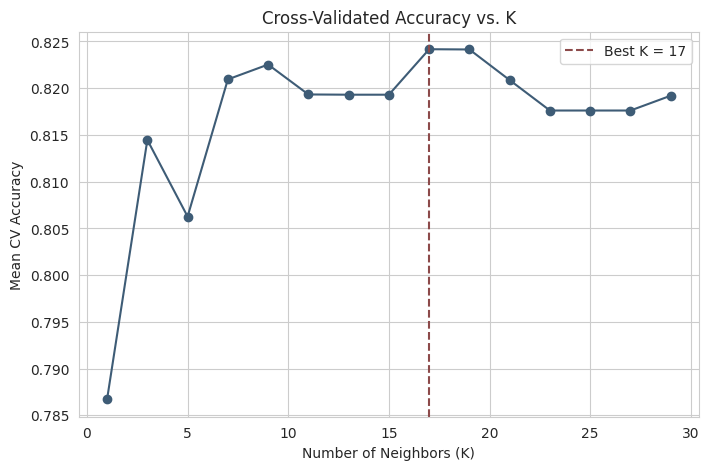

In [ ]:
k_values = list(range(1, 31, 2))  # odd K avoids tie votes for binary classification
cv_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_scaled, y_train, cv=10, scoring="accuracy")
    cv_scores.append(scores.mean())

best_k = k_values[int(np.argmax(cv_scores))]
print(f"Best K found: {best_k} (CV accuracy = {max(cv_scores):.4f})")

plt.figure(figsize=(8, 5))
plt.plot(k_values, cv_scores, marker="o", color="#3E5C76")
plt.axvline(best_k, color="#8C4A4A", linestyle="--", label=f"Best K = {best_k}")
plt.title("Cross-Validated Accuracy vs. K")
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Mean CV Accuracy")
plt.legend()
plt.show()

## 8. Train the Final KNN Classifier

In [ ]:
knn_final = KNeighborsClassifier(n_neighbors=best_k, metric="minkowski", p=2)  # p=2 -> Euclidean distance
knn_final.fit(X_train_scaled, y_train)

y_pred = knn_final.predict(X_test_scaled)
y_proba = knn_final.predict_proba(X_test_scaled)[:, 1]

print(f"KNN classifier trained with K = {best_k}")

KNN classifier trained with K = 17


## 9. Model Evaluation

In [ ]:
acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {acc:.4f}\n")
print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=["No Diabetes", "Diabetes"]))

Test Accuracy: 0.7857

Classification Report:

              precision    recall  f1-score   support

 No Diabetes       0.83      0.85      0.84       100
    Diabetes       0.71      0.67      0.69        54

    accuracy                           0.79       154
   macro avg       0.77      0.76      0.76       154
weighted avg       0.78      0.79      0.78       154



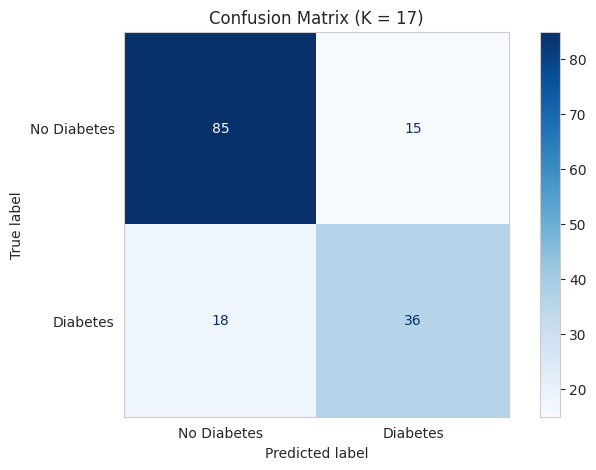

In [ ]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Diabetes", "Diabetes"])
disp.plot(cmap="Blues", values_format="d")
plt.title(f"Confusion Matrix (K = {best_k})")
plt.grid(False)
plt.show()

### ROC Curve

The ROC curve shows the trade-off between true-positive rate and false-positive rate across classification thresholds. AUC (Area Under the Curve) summarizes overall discriminative ability — 0.5 is random guessing, 1.0 is a perfect classifier.

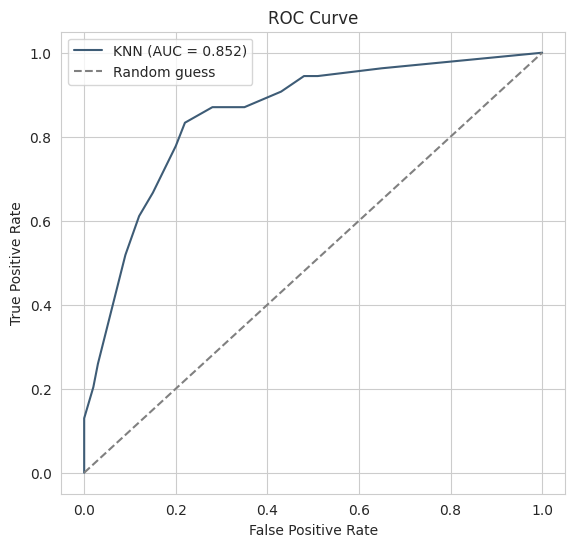

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(6.5, 6))
plt.plot(fpr, tpr, color="#3E5C76", label=f"KNN (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## 10. Predicting a New Patient

Example of how to classify a brand-new, unseen patient record using the trained pipeline (scale, then predict).

In [ ]:
new_patient = pd.DataFrame([{
    "Pregnancies": 2,
    "Glucose": 130,
    "BloodPressure": 70,
    "SkinThickness": 25,
    "Insulin": 100,
    "BMI": 31.5,
    "DiabetesPedigreeFunction": 0.45,
    "Age": 35
}])

new_patient_scaled = scaler.transform(new_patient)
pred_class = knn_final.predict(new_patient_scaled)[0]
pred_proba = knn_final.predict_proba(new_patient_scaled)[0, 1]

label = "Diabetes" if pred_class == 1 else "No Diabetes"
print(f"Prediction: {label}  (probability of diabetes = {pred_proba:.2f})")

Prediction: No Diabetes  (probability of diabetes = 0.18)


**Get the input from User**

In [ ]:
def get_user_input(feature_ranges):
    """Prompt the user for each feature, show its valid range, and validate the entry."""
    user_values = {}
    print("Enter the patient's details below.")
    print("(Valid ranges are shown based on the training data.)\n")
    for feature, (low, high) in feature_ranges.items():
        while True:
            raw = input(f"{feature} (range: {low:g} - {high:g}): ").strip()
            try:
                value = float(raw)
            except ValueError:
                print(" Please enter a numeric value.")
                continue
            if value < low or value > high:
                print(f" Out of range. Please enter a value between {low:g} and {high:g}.")
                continue
            user_values[feature] = value
            break
    return user_values

# Build valid ranges directly from the cleaned training data (min, max per feature)
feature_ranges = {col: (df_clean[col].min(), df_clean[col].max()) for col in X.columns}

user_values = get_user_input(feature_ranges)
new_patient = pd.DataFrame([user_values])[X.columns]  # keep the same column order as training

new_patient_scaled = scaler.transform(new_patient)
pred_class = knn_final.predict(new_patient_scaled)[0]
pred_proba = knn_final.predict_proba(new_patient_scaled)[0, 1]

label = "Diabetes" if pred_class == 1 else "No Diabetes"
print("\n--- Patient entered ---")
print(new_patient.to_string(index=False))
print(f"\nPrediction: {label}  (probability of diabetes = {pred_proba:.2f})")

Enter the patient's details below.
(Valid ranges are shown based on the training data.)

Pregnancies (range: 0 - 17): 10
Glucose (range: 44 - 199): 78
BloodPressure (range: 24 - 122): 76
SkinThickness (range: 7 - 99): 89
Insulin (range: 14 - 846): 90
BMI (range: 18.2 - 67.1): 79.0
 Out of range. Please enter a value between 18.2 and 67.1.
BMI (range: 18.2 - 67.1): 19.0
DiabetesPedigreeFunction (range: 0.078 - 2.42): 2.1
Age (range: 21 - 81): 35

--- Patient entered ---
 Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin  BMI  DiabetesPedigreeFunction  Age
        10.0     78.0           76.0           89.0     90.0 19.0                       2.1 35.0

Prediction: Diabetes  (probability of diabetes = 0.59)


### Save Model

In [ ]:
from sklearn.pipeline import Pipeline
import joblib

pipeline = Pipeline([
    ('scaler', scaler),
    ('knn', knn_final)
])

joblib.dump(pipeline, "KNN_Diabetes_Model.joblib")

['KNN_Diabetes_Model.joblib']

#### **Flask Code :-**


In [ ]:
from flask import Flask, render_template, request
from joblib import load
import numpy as np

app = Flask(__name__)

# Load complete KNN pipeline
# Pipeline contains StandardScaler + KNN
model = load("KNN_Diabetes_Model.joblib")


@app.route('/')
def home():
    return render_template("index.html")


@app.route('/predict', methods=['POST'])
def predict():

    # -----------------------------
    # Get input values
    # -----------------------------
    pregnancies = float(request.form['pregnancies'])
    glucose = float(request.form['glucose'])
    blood_pressure = float(request.form['blood_pressure'])
    skin_thickness = float(request.form['skin_thickness'])
    insulin = float(request.form['insulin'])
    bmi = float(request.form['bmi'])
    diabetes_pedigree = float(request.form['diabetes_pedigree'])
    age = float(request.form['age'])


    # -----------------------------
    # Create input array
    # IMPORTANT:
    # Feature order must match
    # training data
    # -----------------------------
    input_data = np.array([[
        pregnancies,
        glucose,
        blood_pressure,
        skin_thickness,
        insulin,
        bmi,
        diabetes_pedigree,
        age
    ]])


    # -----------------------------
    # Prediction
    # Pipeline automatically:
    # 1. Scales the input
    # 2. Applies KNN
    # -----------------------------
    prediction = model.predict(input_data)


    # -----------------------------
    # Convert prediction to result
    # -----------------------------
    if prediction[0] == 1:
        result = "Diabetes"
    else:
        result = "No Diabetes"


    # -----------------------------
    # Send result to HTML
    # -----------------------------
    return render_template(
        "index.html",
        prediction_text=f"Prediction : {result}"
    )


if __name__ == "__main__":
    app.run(debug=True)

 * Serving Flask app '__main__'
 * Debug mode: on


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug: * Restarting with watchdog (inotify)


#### **HTML Code :-**

In [ ]:
<!DOCTYPE html>
<html lang="en">

<head>

    <meta charset="UTF-8">

    <meta name="viewport" content="width=device-width, initial-scale=1.0">

    <title>KNN Diabetes Classification</title>

    <style>

        *{
            box-sizing: border-box;
        }

        body {
            margin: 0;
            font-family: Arial, sans-serif;
            background: #f4f7fb;
            color: #333;
        }

        .container {
            width: 95%;
            max-width: 1000px;
            margin: 30px auto;
        }

        .card {
            background: white;
            padding: 30px;
            border-radius: 12px;
            box-shadow: 0 4px 15px rgba(0, 0, 0, 0.08);
        }

        h1 {
            text-align: center;
            color: #1769aa;
            margin-bottom: 8px;
        }

        .subtitle {
            text-align: center;
            color: #666;
            margin-bottom: 10px;
        }

        .instruction {
            text-align: center;
            color: #777;
            font-size: 13px;
            margin-bottom: 25px;
        }

        .section-title {
            background: #eaf3fb;
            color: #1769aa;
            padding: 12px 15px;
            border-radius: 6px;
            margin-top: 25px;
            margin-bottom: 15px;
            font-size: 18px;
            font-weight: bold;
        }

        .section-note {
            font-size: 13px;
            color: #777;
            margin-bottom: 12px;
        }

        .input-grid {
            display: grid;
            grid-template-columns: repeat(2, 1fr);
            gap: 15px;
        }

        .input-group {
            display: flex;
            flex-direction: column;
        }

        label {
            font-size: 14px;
            margin-bottom: 6px;
            font-weight: bold;
        }

        input {
            padding: 10px;
            border: 1px solid #ccc;
            border-radius: 5px;
            font-size: 14px;
        }

        input:focus {
            outline: none;
            border-color: #1769aa;
        }

        input::placeholder {
            color: #999;
            font-size: 12px;
        }

        .button-area {
            text-align: center;
            margin-top: 30px;
        }

        button {
            background: #1769aa;
            color: white;
            border: none;
            padding: 13px 35px;
            border-radius: 6px;
            font-size: 16px;
            cursor: pointer;
        }

        button:hover {
            background: #0d568d;
        }

        .result {
            margin-top: 25px;
            padding: 15px;
            text-align: center;
            background: #e8f7ed;
            color: #218838;
            border-radius: 6px;
            font-size: 18px;
            font-weight: bold;
        }

        .probability {
            margin-top: 10px;
            padding: 12px;
            text-align: center;
            background: #eef5ff;
            color: #1769aa;
            border-radius: 6px;
            font-size: 15px;
            font-weight: bold;
        }

        .footer {
            text-align: center;
            color: #777;
            margin-top: 20px;
            font-size: 13px;
        }

        @media(max-width: 700px) {

            .input-grid {
                grid-template-columns: 1fr;
            }

            .card {
                padding: 20px;
            }

        }

    </style>

</head>


<body>

<div class="container">

    <div class="card">

        <h1>KNN Diabetes Classification</h1>

        <div class="subtitle">
            Classification using K-Nearest Neighbors
        </div>

        <div class="instruction">
            Enter the patient's 8 medical details below.
        </div>


        <form action="/predict" method="POST">


            <!-- ================================================= -->
            <!-- PATIENT FEATURES -->
            <!-- ================================================= -->

            <div class="section-title">
                Patient Medical Features
            </div>

            <div class="section-note">
                Enter numerical values for all the features used by the KNN classifier.
            </div>

            <div class="input-grid">


                <!-- Pregnancies -->

                <div class="input-group">

                    <label>Pregnancies</label>

                    <input type="number"
                           step="any"
                           name="pregnancies"
                           placeholder="Example: 2"
                           min="0"
                           required>

                </div>


                <!-- Glucose -->

                <div class="input-group">

                    <label>Glucose</label>

                    <input type="number"
                           step="any"
                           name="glucose"
                           placeholder="Example: 130"
                           min="0"
                           required>

                </div>


                <!-- Blood Pressure -->

                <div class="input-group">

                    <label>Blood Pressure</label>

                    <input type="number"
                           step="any"
                           name="blood_pressure"
                           placeholder="Example: 70"
                           min="0"
                           required>

                </div>


                <!-- Skin Thickness -->

                <div class="input-group">

                    <label>Skin Thickness</label>

                    <input type="number"
                           step="any"
                           name="skin_thickness"
                           placeholder="Example: 25"
                           min="0"
                           required>

                </div>


                <!-- Insulin -->

                <div class="input-group">

                    <label>Insulin</label>

                    <input type="number"
                           step="any"
                           name="insulin"
                           placeholder="Example: 100"
                           min="0"
                           required>

                </div>


                <!-- BMI -->

                <div class="input-group">

                    <label>BMI</label>

                    <input type="number"
                           step="any"
                           name="bmi"
                           placeholder="Example: 31.5"
                           min="0"
                           required>

                </div>


                <!-- Diabetes Pedigree Function -->

                <div class="input-group">

                    <label>Diabetes Pedigree Function</label>

                    <input type="number"
                           step="any"
                           name="diabetes_pedigree"
                           placeholder="Example: 0.45"
                           min="0"
                           required>

                </div>


                <!-- Age -->

                <div class="input-group">

                    <label>Age</label>

                    <input type="number"
                           step="any"
                           name="age"
                           placeholder="Example: 35"
                           min="0"
                           required>

                </div>


            </div>


            <!-- ================================================= -->
            <!-- PREDICT BUTTON -->
            <!-- ================================================= -->

            <div class="button-area">

                <button type="submit">
                    Predict
                </button>

            </div>


        </form>


        <!-- ================================================= -->
        <!-- RESULT -->
        <!-- ================================================= -->

        {% if prediction_text %}

        <div class="result">
            {{ prediction_text }}
        </div>

        {% endif %}


        {% if probability %}

        <div class="probability">
            {{ probability }}
        </div>

        {% endif %}


    </div>


    <div class="footer">

        K-Nearest Neighbors Classifier |
        Pima Indians Diabetes Dataset

    </div>

</div>


</body>

</html>

SyntaxError: invalid decimal literal (1886318708.py, line 27)